In [234]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
%matplotlib inline

import csv


# Functions

In [235]:
def comma_to_left(string, index) -> bool:
    '''
    Checks if there is a comma to the left of the index in the string, ignoring spaces.
    '''
    while index >= 1:
        if string[index - 1] == ',':
            return True
        if string[index - 1] == ' ':
            index -= 1
        else:
            return False
    return False

def strip_optional_tags(string):
    '''
    Strips "optional" tags from the string, and strips descriptions of ingredients in parentheses
    '''
    # First, remove simple substrings
    string = string.replace("[", "").replace("]", "")
    string = string.replace("optionally", "").replace("optional", "")
    string = string.replace(":", "")
    
    # Handle parentheses: find all "("s
    # If no comma to the left, delete everything from "(" to ")"
    # If comma to the left, just delete "(" and ")"
    result = []
    i = 0
    while i < len(string):
        if string[i] == '(':
            # Find the closing parenthesis
            close_idx = string.find(')', i)
            if close_idx == -1:
                # No closing paren found, keep the rest
                result.append(string[i:])
                break
            
            # Check if there's a comma to the left
            if comma_to_left(string, i):
                # Just delete "(" and ")", keep the content
                result.append(string[i+1:close_idx])
                i = close_idx + 1
            else:
                # Delete all text from "(" to ")" inclusive
                i = close_idx + 1
        else:
            result.append(string[i])
            i += 1
    
    return ''.join(result)

def strip_optional_ingredients(string):
    '''
    Strips "optional" ingredients from the string, as well as descriptions of ingredients in parentheses.
    '''
    # First pass: Look for "(" or "[" from left to right
    # If one is found and there's a comma to the left, delete everything from that comma to the end
    i = 0
    while i < len(string):
        if string[i] in '([':
            if comma_to_left(string, i):
                # Delete everything from the comma to the end of the string
                j = i - 1
                while j >= 0:
                    if string[j] == ',':
                        string = string[:j]
                        break
                    j -= 1
                break
        i += 1
    
    # Second pass: Search for "(optional)" and "[optional]" repeatedly
    while True:
        idx1 = string.find("(optional)")
        idx2 = string.find("[optional]")
        
        if idx1 == -1 and idx2 == -1:
            break
        
        # Find which one comes first
        idx = -1
        pattern_len = 0
        if idx1 != -1 and idx2 != -1:
            idx = min(idx1, idx2)
            pattern_len = 10 if idx == idx1 else 10
        elif idx1 != -1:
            idx = idx1
            pattern_len = 10
        else:
            idx = idx2
            pattern_len = 10
        
        # Find the first comma to the left, delete from comma to end of pattern
        j = idx - 1
        comma_idx = -1
        while j >= 0:
            if string[j] == ',':
                comma_idx = j
                break
            j -= 1
        
        if comma_idx != -1:
            # Delete from comma to the end of the pattern
            string = string[:comma_idx] + string[idx + pattern_len:]
        else:
            # No comma found, just remove the pattern
            string = string[:idx] + string[idx + pattern_len:]
    
    # Final pass: Strip everything in parentheses, including the parentheses themselves
    # get rid of the descriptions of ingredients in parentheses, e.g. "kalabasa (squash)"
    result = []
    i = 0
    while i < len(string):
        if string[i] == '(':
            # Find the closing parenthesis
            close_idx = string.find(')', i)
            if close_idx == -1:
                # No closing paren found, keep the rest
                result.append(string[i:])
                break
            # Skip everything from "(" to ")" inclusive
            i = close_idx + 1
        else:
            result.append(string[i])
            i += 1
    
    return ''.join(result).strip()


def clean_ingredient_list(string):
    '''
    Strips whitespace and empty ingredients so that we can easily split by comma to get a clean list
    Also splits on "and" and "or" and removes periods
    '''
    normalized = re.sub(r"\bor\b", ",", string, flags=re.IGNORECASE)
    normalized = re.sub(r"\band\b", ",", normalized, flags=re.IGNORECASE)
    return [ingredient.lower().replace(".", "").strip() for ingredient in normalized.split(",") if ingredient.strip()]

def countries_to_array(string):
    '''
    Converts a string of countries separated by semicolons into an array of countries, stripping whitespace.
    '''
    return [country.strip() for country in string.split(";") if country.strip()]

## Testing

In [236]:
print(strip_optional_tags("salt, sugar, pepper (optional), garlic (optional), onion (optional)"))
print(strip_optional_tags("salt, (optional: garlic, sugar, etc.)"))
print(strip_optional_tags("salt, sugar, pepper [optional], garlic [optional], onion [optional]"))
print(strip_optional_tags("salt, sugar, (optional) pepper, (optional) garlic, (optional) onion"))
print(strip_optional_tags("salt, [green onions (optional)], [red onions (optional)]"))
print(strip_optional_tags("salt, (optional: garlic), (optionally: sugar)"))
print(strip_optional_tags("salt, (optional garlic), (optional sugar)"))
print(strip_optional_tags("salt, kalabasa (squash)"))
print(strip_optional_tags("salt, kalabasa (squash), (optional) garlic"))

print("\n" + strip_optional_tags("salt, sugar, (optionally pepper), (optional garlic)"))

salt, sugar, pepper , garlic , onion 
salt,  garlic, sugar, etc.
salt, sugar, pepper , garlic , onion 
salt, sugar,  pepper,  garlic,  onion
salt, green onions , red onions 
salt,  garlic,  sugar
salt,  garlic,  sugar
salt, kalabasa 
salt, kalabasa ,  garlic

salt, sugar,  pepper,  garlic


In [237]:
print(strip_optional_ingredients("salt, sugar, pepper (optional), garlic (optional), onion (optional)"))
print(strip_optional_ingredients("salt, (optional: garlic, sugar, etc.)"))
print(strip_optional_ingredients("salt, sugar, pepper [optional], garlic [optional], onion [optional]"))
print(strip_optional_ingredients("salt, sugar, (optional) pepper, (optional) garlic, (optional) onion"))
print(strip_optional_ingredients("salt, [green onions (optional)], [red onions (optional)]"))
print(strip_optional_ingredients("salt, (optional: garlic), (optionally: sugar)"))
print(strip_optional_ingredients("salt, (optional garlic), (optional sugar)"))
print(strip_optional_ingredients("salt, kalabasa (squash)"))
print(strip_optional_ingredients("salt, kalabasa (squash), (optional) garlic"))

salt, sugar
salt
salt, sugar
salt, sugar
salt
salt
salt
salt, kalabasa
salt, kalabasa


In [238]:
clean_ingredient_list("salt   , meat or fish,     onion, etc")

['salt', 'meat', 'fish', 'onion', 'etc']

# Data Cleaning

In [239]:
df = pd.read_csv('data.csv')

cleaned_df = df.copy().drop("alternate_names", axis=1)

cleaned_df['ingredients'] = cleaned_df['ingredients'].apply(strip_optional_tags).apply(clean_ingredient_list)
cleaned_df['countries_of_origin'] = cleaned_df['countries_of_origin'].apply(countries_to_array)

In [240]:
cleaned_df.head()

,dish_name,countries_of_origin,ingredients
0,Cepelinai,[Lithuania],"[potatoes, ground meat, onions, bacon, sour cr..."
1,Msabbaha,"[Oman, Jordan, Bahrain, Palestine, Qatar, Unit...","[chickpeas, tahini, lemon juice, garlic, olive..."
2,Lazarakia,"[Greece, Cyprus]","[flour, yeast, water, sugar, olive oil, salt, ..."
3,Dressed Crab,[United Kingdom],"[crab meat, mayonnaise, lemon juice, breadcrum..."
4,Dak-galbi,[South Korea],"[chicken, gochujang, soy sauce, garlic, ginger..."


In [241]:
cleaned_df['countries_of_origin'].explode().value_counts().head(15)

countries_of_origin
United States     100
Indonesia          75
Philippines        71
United Kingdom     70
Japan              68
China              63
Italy              55
India              55
Spain              54
South Korea        51
Germany            49
France             49
Canada             43
Turkey             42
Vietnam            37
Name: count, dtype: int64

In [242]:
# filter out duplicates
unique_dishes_df = cleaned_df.drop_duplicates(subset=['dish_name'])
len(unique_dishes_df)

1142

<Axes: xlabel='count', ylabel='Count'>

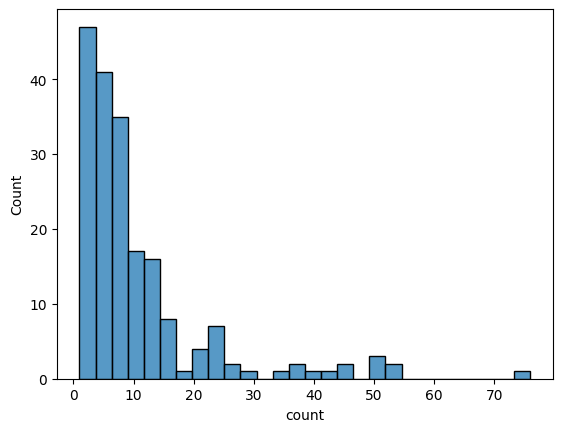

In [243]:
sns.histplot(unique_dishes_df['countries_of_origin'].explode().value_counts())

### Collapse similar ingredient variants (plural, spacing, accents, etc.)

In [244]:
import inflect
import unicodedata
import re

p = inflect.engine()

# Normalize ingredient strings to collapse accent, apostrophe, and hyphen variants,
# while preserving spaces so canonical multi-word ingredients stay spaced.
def normalize_ingredient(ingredient):
    if not isinstance(ingredient, str):
        return ingredient
    ingredient = unicodedata.normalize('NFKD', ingredient)
    ingredient = ''.join(ch for ch in ingredient if not unicodedata.combining(ch))
    ingredient = ingredient.lower()
    ingredient = ingredient.replace('-', ' ')
    ingredient = re.sub(r"[’`´]", "'", ingredient)
    ingredient = ingredient.replace("'", '')
    ingredient = re.sub(r'\s+', ' ', ingredient).strip()
    return ingredient

# Singularize ingredients after normalization
def singularize_ingredient(ingredient):
    if not isinstance(ingredient, str):
        return ingredient
    ingredient = normalize_ingredient(ingredient)
    try:
        return p.singular_noun(ingredient) or ingredient
    except Exception:
        return ingredient

unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(
    lambda lst: [singularize_ingredient(ing) for ing in lst]
)

# Map joined variants to spaced canonical forms when a spaced form exists.
joined_to_spaced = {}
for ing in unique_dishes_df.loc[:, 'ingredients'].explode().dropna().unique():
    joined = ing.replace(' ', '')
    if ' ' in ing:
        joined_to_spaced[joined] = ing

unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(
    lambda lst: [joined_to_spaced.get(ing.replace(' ', ''), ing) for ing in lst]
)


In [245]:
from fuzzywuzzy import fuzz
from itertools import combinations

# Get unique ingredients from exploded list
ingredients = unique_dishes_df['ingredients'].explode().dropna().unique()

# Generate all pairs
pairs = list(combinations(ingredients, 2))

# Calculate similarities
similarities = [(pair, fuzz.ratio(pair[0], pair[1])) for pair in pairs]

# Sort by similarity descending
similarities.sort(key=lambda x: x[1], reverse=True)

In [246]:
similarities[:40]

[(('pomegranate seed', 'pomgranate seed'), 97),
 (('corn starch', 'acorn starch'), 96),
 (('goats milk', 'goat milk'), 95),
 (('sheep milk', 'sheeps milk'), 95),
 (('pig blood', 'pigs blood'), 95),
 (('pig tail', 'pigs tail'), 94),
 (('red chili pepper', 'dried chili pepper'), 94),
 (('gelatin', 'gelatine'), 93),
 (('spaetzle', 'spatzle'), 93),
 (('sodium nitrite', 'sodium nitrate'), 93),
 (('habanero pepper', 'habenero pepper'), 93),
 (('chili pepper', 'chile pepper'), 92),
 (('dried shrimp', 'fried shrimp'), 92),
 (('pasilla chili', 'pasilla chile'), 92),
 (('artificial flavoring', 'artificial flavor'), 92),
 (('green chili', 'green chile'), 91),
 (('powdered sugar for dusting', 'powdered sugar for frosting'), 91),
 (('dried fish', 'fried fish'), 90),
 (('red onion', 'fried onion'), 90),
 (('dried chili', 'red chili'), 90),
 (('dried red chili pepper', 'dried chili pepper'), 90),
 (('salt meat', 'salted meat'), 90),
 (('dried bean', 'red bean'), 89),
 (('bean', 'besan'), 89),
 (('sal

In [247]:
unique_dishes_df['ingredients'].explode().value_counts().head(10)

ingredients
salt      630
garlic    478
onion     410
sugar     348
water     273
egg       248
butter    246
pepper    219
flour     192
tomato    170
Name: count, dtype: int64

In [248]:
def display_ingredients(dish_name):
    ingredients = cleaned_df.loc[cleaned_df['dish_name'] == dish_name, 'ingredients'].values
    if len(ingredients) > 0:
        return ", ".join(ingredients[0])
    else:
        return []

# Model

**Will be useful to refactor and do GridSearchCV on RandomForest model varying num trees, max depth, balancing parameter, and uncommon country training drop size**

In [249]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

# Keep the full multi-country lists for evaluation, but split before assigning single labels.
model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()
train_df, test_df = train_test_split(model_df, test_size=0.2, random_state=42)

# Compute the most common country labels from the training set only.
train_country_counts = train_df['countries_of_origin'].explode().value_counts()

def most_common_country(country_list):
    if not country_list:
        return np.nan
    ranked = sorted(country_list, key=lambda c: train_country_counts.get(c, 0), reverse=True)
    return ranked[0]

# convert multi-label to single-label for training by taking the most common country in the training set among the valid countries for each dish
#train_df['target_country'] = train_df['countries_of_origin'].apply(most_common_country)

# expand multi-labels into separate rows for training, 1 row per dish-country_of_origin pair
train_df = train_df.explode('countries_of_origin').rename(columns={'countries_of_origin': 'target_country'}).reset_index(drop=True)

# filter out less common countries from the training set to reduce noise
uncommon_countries = train_country_counts.tail(150).index
train_df = train_df[~train_df['target_country'].isin(uncommon_countries)]


mlb = MultiLabelBinarizer(sparse_output=False)
mlb.fit(model_df['ingredients'])
X_train = pd.DataFrame(mlb.transform(train_df['ingredients']), columns=mlb.classes_, index=train_df.index)
X_test = pd.DataFrame(mlb.transform(test_df['ingredients']), columns=mlb.classes_, index=test_df.index)

y_train = train_df['target_country']
y_test_multi = test_df['countries_of_origin']

print('Training rows:', len(train_df))
print('Test rows:', len(test_df))
print('Training country counts:', y_train.value_counts().head(10).to_dict())
print('Example test labels (multi-country):', y_test_multi.head().tolist())


Training rows: 907
Test rows: 229
Training country counts: {'United States': 68, 'China': 47, 'Japan': 43, 'Indonesia': 41, 'Philippines': 38, 'Italy': 38, 'Spain': 36, 'United Kingdom': 36, 'Germany': 31, 'India': 31}
Example test labels (multi-country): [['Mexico'], ['France'], ['Austria', 'Germany'], ['Uruguay', 'Argentina'], ['Sri Lanka', 'India']]


### Decision Tree

In [250]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# example display count
n = 8
display_ings = False

clf = DecisionTreeClassifier(max_depth = 150, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())


Train set: (907, 1805) Test set: (229, 1805)
Hold-out accuracy (single-label prediction vs. any true country): 0.20087336244541484

Predicted vs actual multi-country labels for first examples:
Mole De Olla: predicted Peru, actual=['Mexico'], incorrect
Bayonne Ham: predicted China, actual=['France'], incorrect
Wiener Schnitzel: predicted United States, actual=['Austria', 'Germany'], incorrect
Submarino: predicted United States, actual=['Uruguay', 'Argentina'], incorrect
Puttu: predicted India, actual=['Sri Lanka', 'India'], correct
Butifarra Soledeñas: predicted Armenia, actual=['Colombia'], incorrect
Mont Kywe The: predicted Thailand, actual=['Myanmar'], incorrect
Qarymutah: predicted Canada, actual=['Syria'], incorrect

Top ingredient importances:
mirin         0.020616
shallot       0.019287
cilantro      0.019247
garlic        0.017569
olive oil     0.015877
sesame oil    0.015374
salt          0.014649
fish sauce    0.012817
cumin         0.012586
pepper        0.012585
pork       

In [251]:
display_ingredients('Qarymutah')

'bulgur, onion, cucumber, tomato, parsley, lemon juice, mint, sumac'

How did it go USA.........

In [252]:
y_train[y_train == 'Syria']

Series([], Name: target_country, dtype: object)

It turns out setting the training label to the most frequent of the valid countries filters out Syria entirely

### Random Forest

In [253]:
from sklearn.ensemble import RandomForestClassifier

# example display count
n = 8
display_ings = False

clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=30, class_weight='balanced')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())

Train set: (907, 1805) Test set: (229, 1805)
Hold-out accuracy (single-label prediction vs. any true country): 0.3406113537117904

Predicted vs actual multi-country labels for first examples:
Mole De Olla: predicted Mexico, actual=['Mexico'], correct
Bayonne Ham: predicted Philippines, actual=['France'], incorrect
Wiener Schnitzel: predicted France, actual=['Austria', 'Germany'], incorrect
Submarino: predicted United Kingdom, actual=['Uruguay', 'Argentina'], incorrect
Puttu: predicted India, actual=['Sri Lanka', 'India'], correct
Butifarra Soledeñas: predicted Peru, actual=['Colombia'], incorrect
Mont Kywe The: predicted India, actual=['Myanmar'], incorrect
Qarymutah: predicted Turkey, actual=['Syria'], incorrect

Top ingredient importances:
olive oil       0.012282
water           0.011436
garlic          0.011337
salt            0.010890
onion           0.010765
shallot         0.010553
soy sauce       0.010457
black pepper    0.010151
egg             0.009913
sesame oil      0.00929

In [254]:
pd.Series(y_pred).value_counts() / len(y_pred) * 100

Germany           11.790393
United Kingdom    10.480349
United States      7.860262
Canada             6.986900
Italy              5.676856
Spain              5.240175
France             4.366812
Philippines        4.366812
India              3.930131
Indonesia          3.493450
Vietnam            3.493450
Mexico             3.493450
Turkey             3.056769
Thailand           3.056769
China              2.620087
South Korea        2.183406
Japan              1.746725
Ukraine            1.746725
Peru               1.746725
Iran               1.310044
Nepal              1.310044
Georgia            1.310044
Brazil             1.310044
Nigeria            1.310044
Sweden             0.873362
Tunisia            0.873362
North Korea        0.873362
Azerbaijan         0.873362
Algeria            0.436681
Malaysia           0.436681
Armenia            0.436681
Australia          0.436681
Hong Kong          0.436681
Pakistan           0.436681
Name: count, dtype: float64

### Balanced Random Forest

In [262]:
from imblearn.ensemble import BalancedRandomForestClassifier

# example display count
n = 8
display_ings = False

clf = BalancedRandomForestClassifier(random_state=42, n_estimators=300, max_depth=30, class_weight='balanced')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())

Train set: (907, 1805) Test set: (229, 1805)
Hold-out accuracy (single-label prediction vs. any true country): 0.27510917030567683

Predicted vs actual multi-country labels for first examples:
Mole De Olla: predicted Mexico, actual=['Mexico'], correct
Bayonne Ham: predicted Sweden, actual=['France'], incorrect
Wiener Schnitzel: predicted Ukraine, actual=['Austria', 'Germany'], incorrect
Submarino: predicted United Kingdom, actual=['Uruguay', 'Argentina'], incorrect
Puttu: predicted India, actual=['Sri Lanka', 'India'], correct
Butifarra Soledeñas: predicted Armenia, actual=['Colombia'], incorrect
Mont Kywe The: predicted Vietnam, actual=['Myanmar'], incorrect
Qarymutah: predicted Iran, actual=['Syria'], incorrect

Top ingredient importances:
olive oil       0.013734
water           0.011373
salt            0.010975
onion           0.010577
ginger          0.010415
black pepper    0.010320
garlic          0.010286
sesame oil      0.010074
butter          0.009978
palm oil        0.00973

remember to strip spaces when collapsing ings for easier use!!!

In [256]:
def preprocess_ingredients(ingredient_string):
    cleaned_list = clean_ingredient_list(strip_optional_tags(ingredient_string))
    normalized_list = [normalize_ingredient(ing) for ing in cleaned_list]
    singularized_list = [singularize_ingredient(ing) for ing in normalized_list]
    return singularized_list

In [257]:
def predict_country(ingredient_string):
    # Preprocess the ingredients
    processed_ings = preprocess_ingredients(ingredient_string)
    print(f"Processed ingredients: {processed_ings}")

    # Create feature vector
    X_new = pd.DataFrame(mlb.transform([processed_ings]), columns=mlb.classes_)

    # Train and predict with Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=30)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_new)[0]

    probs = rf_model.predict_proba(X_new)
    top_n = 5
    top_n_indices = np.argsort(probs, axis=1)[:, :-top_n-1:-1]
    top_n_predictions = rf_model.classes_[top_n_indices]

    print(f"Random Forest prediction: {rf_pred}")
    print(f"2nd prediction: {top_n_predictions[0][1]}")
    print(f"3rd prediction: {top_n_predictions[0][2]}")
    print(f"4th prediction: {top_n_predictions[0][3]}")
    print(f"5th prediction: {top_n_predictions[0][4]}")


In [258]:
predict_country("Cabbage, carrots, radishes, ginger, garlic, chili peppers, salt, water, Sichuan peppercorns, sugar (optional), rice vinegar (optional).")

Processed ingredients: ['cabbage', 'carrot', 'radish', 'ginger', 'garlic', 'chili pepper', 'salt', 'water', 'sichuan peppercorn', 'sugar', 'rice vinegar']
Random Forest prediction: Philippines
2nd prediction: China
3rd prediction: South Korea
4th prediction: United States
5th prediction: Mexico


In [259]:
predict_country("Rice, water, salt (optional).")

Processed ingredients: ['rice', 'water', 'salt']
Random Forest prediction: India
2nd prediction: United States
3rd prediction: China
4th prediction: Japan
5th prediction: Indonesia


In [260]:
predict_country("Wheat flour, butter, milk, egg yolk, sugar, ground almonds, ground hazelnuts, ground walnuts, cardamom, (optional saffron), (optional rose water), (optional vanilla), (optional baking powder), (optional salt)")

Processed ingredients: ['wheat flour', 'butter', 'milk', 'egg yolk', 'sugar', 'ground almond', 'ground hazelnut', 'ground walnut', 'cardamom', 'saffron', 'rose water', 'vanilla', 'baking powder', 'salt']


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['ground hazelnut'] will be ignored
  warnings.warn(


Random Forest prediction: Iran
2nd prediction: India
3rd prediction: Pakistan
4th prediction: United Kingdom
5th prediction: United States


In [261]:
predict_country("marjoram, bay leaves, mustard")

Processed ingredients: ['marjoram', 'bay leaf', 'mustard']
Random Forest prediction: United States
2nd prediction: Germany
3rd prediction: United Kingdom
4th prediction: Canada
5th prediction: France
